# LoanShield: Hyperparameter Tuning (Random Forest)
In this notebook, we optimize the **Random Forest** model to improve its performance.

**Objective:**
Use `RandomizedSearchCV` to find the best hyperparameters:
1. **`n_estimators`**: Number of trees.
2. **`max_depth`**: Maximum levels in each tree (controls overfitting).
3. **`min_samples_split`**: Minimum data points required to split a node.
4. **`class_weight`**: To handle the imbalance (88% vs 12%).

**Why Random Forest?**
It was selected as the best performing baseline model with high accuracy and stability.

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Configuration
sns.set_style("whitegrid")

In [2]:
# 2. Load Processed Data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.flatten()
y_test = pd.read_csv('../data/processed/y_test.csv').values.flatten()

print(f"Data Loaded. Train Shape: {X_train.shape}")

Data Loaded. Train Shape: (204277, 22)


## Part 1: Define the Hyperparameter Grid
We define a range of possibilities for the model to try.

In [3]:
# Define the parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],        # More trees = better performance but slower
    'max_depth': [10, 20, 30, None],        # None means grow until pure (risk of overfitting)
    'min_samples_split': [2, 5, 10],        # Higher numbers prevent overfitting
    'min_samples_leaf': [1, 2, 4],          # Higher numbers prevent overfitting
    'bootstrap': [True, False],             # Method of selecting samples
    'class_weight': ['balanced', 'balanced_subsample', None] # Handle Imbalance
}

print("Parameter Grid Defined.")

Parameter Grid Defined.


## Part 2: Run Randomized Search
We use `RandomizedSearchCV` instead of `GridSearchCV` because checking *every* combination would take hours. Randomized Search samples a fixed number of combinations (e.g., 20) and is much faster.

In [4]:
# Optimization: Use a smaller subset for Hyperparameter Tuning
# Training on 180k rows x 60 models takes too long.
# We will sample 20,000 rows, which is enough to find the best settings.

from sklearn.model_selection import train_test_split

# 1. Create a subset (20,000 rows)
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, 
    train_size=20000, 
    stratify=y_train, 
    random_state=42
)

print(f"Tuning on subset of {X_tune.shape[0]} rows (for speed)...")

# 2. Initialize Base Model
rf = RandomForestClassifier(random_state=42)

# 3. Initialize Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,       # Reduced from 20 to 10 to speed it up further
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

# 4. Fit on the SUBSET
print("Starting Hyperparameter Tuning...")
random_search.fit(X_tune, y_tune)

print("\n🎉 Tuning Complete!")
print(f"Best Parameters: {random_search.best_params_}")

Tuning on subset of 20000 rows (for speed)...
Starting Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

🎉 Tuning Complete!
Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': False}


In [5]:
# Retrain the "Best" model on the FULL dataset
print("Retraining best model on full dataset...")
best_params = random_search.best_params_

best_rf_model = RandomForestClassifier(**best_params, random_state=42)
best_rf_model.fit(X_train, y_train)

print("✅ Best model retrained on full data.")

Retraining best model on full dataset...
✅ Best model retrained on full data.


## Part 3: Evaluate the Best Model
Now we take the "winner" from the search and test it on the **Test Set** (data it has never seen).

--- Final Model Evaluation ---
Accuracy: 0.7933
ROC-AUC: 0.7409

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.83      0.88     45139
           1       0.28      0.48      0.35      5931

    accuracy                           0.79     51070
   macro avg       0.60      0.66      0.61     51070
weighted avg       0.85      0.79      0.82     51070



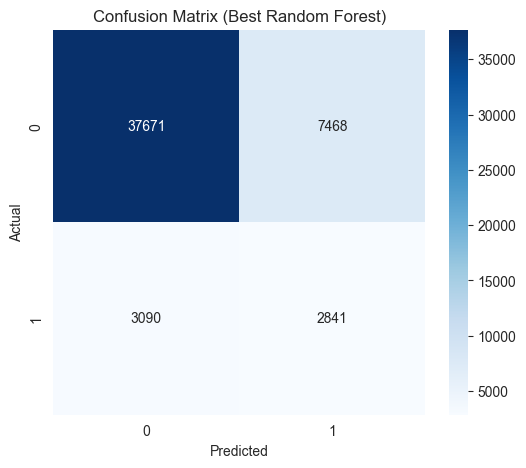

In [6]:
# Get the best model
best_rf_model = random_search.best_estimator_

# Predict on Test Set
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate Metrics
print("--- Final Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Best Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Part 4: Save the Final Model
This tuned Random Forest model is the one we will use in our Website.

In [7]:
# Save the model
model_path = '../webapp/models/best_model.pkl'
joblib.dump(best_rf_model, model_path)

print(f"✅ Final Tuned Model saved to: {model_path}")
print("You are ready for Week 8: Web App Development!")

✅ Final Tuned Model saved to: ../webapp/models/best_model.pkl
You are ready for Week 8: Web App Development!
